# seebeck_og


In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad

_cwd = os.getcwd()
if os.path.isfile(os.path.join(_cwd, "Thermo_data_central.csv")):
    ROOT = _cwd
elif os.path.isfile(os.path.join(os.path.dirname(_cwd), "Thermo_data_central.csv")):
    ROOT = os.path.dirname(_cwd)
else:
    ROOT = r"d:\ML CURSOR\MLQGP"
os.chdir(ROOT)
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)
WDIR = os.path.join(ROOT, "mlqgps_model")
BP = os.path.join(ROOT, "CODE OF THE AUTHOR", "QGP_at_finite_baryon_densities-main", "Band_Plotter")
print("ROOT", ROOT)
print("weights", WDIR)


ROOT d:\ML CURSOR\MLQGP
weights d:\ML CURSOR\MLQGP\mlqgps_model


In [3]:
# MLQGPS simple DNN: Input(2) -> Linear(64, swish) x4 -> Linear(1), 2*sigmoid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device", device)

class Net_Mass(nn.Module):
    def __init__(self, input, output):
        super(Net_Mass, self).__init__()
        self.fc1 = nn.Linear(input, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, output)

    def forward(self, x):
        o = self.act(self.fc1(x))
        o = self.act(self.fc2(o))
        o = self.act(self.fc3(o))
        o = self.act(self.fc4(o))
        opt = self.output_layer_act(self.fc5(o))
        return opt

    def act(self, x):
        return x * torch.sigmoid(x)

    def output_layer_act(self, x):
        return torch.sigmoid(x) * 2


device cuda


In [4]:
# partition function of quark and gluon
def lnZ_q(T,  m,  mu, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    rnodes =  torch.exp(-pnodes)
    psqure = pnodes**2
    E = (psqure + m ** 2) ** 0.5
    E_mu = E - mu
    efactor = torch.exp(-E_mu/T)
    f = efactor * eta
    f = f + 1
    f = torch.log(f)
    f = psqure * eta * f
    f = wnodes * f
    f = f/rnodes
    f = torch.sum(f,1)
    return f.reshape(-1,1)

def lnZ_g(T, m, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    
    rnodes =  torch.exp(-pnodes)
    psqure = pnodes**2
    E = (psqure + m ** 2) ** 0.5
    efactor = torch.exp(-E/T)
    f = efactor * eta
    f = f + 1
    f = torch.log(f)
    f = psqure*eta * f
    f = wnodes * f
    f = f/rnodes
    f = torch.sum(f,1)
    return  f.reshape(-1,1)


In [5]:
Mud_net = Net_Mass(2,1).to(device)
Ms_net  = Net_Mass(2,1).to(device)
Mg_net  = Net_Mass(2,1).to(device)
Mud_net.load_state_dict(torch.load(os.path.join(WDIR, "MLQGPS_Mud.pt"), map_location=device, weights_only=False)['state_dict'])
Ms_net.load_state_dict(torch.load(os.path.join(WDIR, "MLQGPS_Ms.pt"), map_location=device, weights_only=False)['state_dict'])
Mg_net.load_state_dict(torch.load(os.path.join(WDIR, "MLQGPS_Mg.pt"), map_location=device, weights_only=False)['state_dict'])
Mud_net.eval(); Ms_net.eval(); Mg_net.eval()
print("Loaded MLQGPS weights from", WDIR)

def emulator(T_values, muB_values):

    # Convert to differentiable tensors
    T = torch.tensor(T_values, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)
    muB = torch.tensor(muB_values, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)

    # Forward pass (entire batch)
    inp = torch.cat((T, muB), dim=1)
    Mud = Mud_net(inp)
    Ms  = Ms_net(inp)
    Mg  = Mg_net(inp)

    # Compute thermodynamic quantities
    coef_ud = 2*2*3/(2*np.pi**2)
    coef_s  = 2*3/(2*np.pi**2)
    coef_g  = 8*2/(2*np.pi**2)

    lnZ_udquark = coef_ud * (lnZ_q(T, Mud, muB/3, 1) + lnZ_q(T, Mud, -muB/3, 1))
    lnZ_squark  = coef_s  * (lnZ_q(T, Ms, muB/3, 1) + lnZ_q(T, Ms, -muB/3, 1))
    lnZ_gluon  = coef_g  * lnZ_g(T, Mg, -1)

    lnZ_tot = lnZ_udquark + lnZ_squark + lnZ_gluon

    dlnZdT =  torch.autograd.grad(lnZ_tot, T, grad_outputs=torch.ones_like(T).to(device),create_graph=True)[0]
    dlnZdmu = torch.autograd.grad(lnZ_tot, muB, grad_outputs=torch.ones_like(muB).to(device),create_graph=True)[0]

        
        
    BaryonNumber = T * dlnZdmu # particle number density
    Pressure = T * lnZ_tot  # pressure
    Entropy = T * dlnZdT  +  lnZ_tot # entropy
    Energy = T * Entropy - Pressure + muB * BaryonNumber  #  energy density  
    TraceAnomaly = (Energy - 3 * Pressure)

    return (
        Mud.detach().cpu().numpy().flatten(),
        Ms.detach().cpu().numpy().flatten(),
        Mg.detach().cpu().numpy().flatten(),
        Pressure.detach().cpu().numpy().flatten(),
        Entropy.detach().cpu().numpy().flatten(),
        Energy.detach().cpu().numpy().flatten(),
        TraceAnomaly.detach().cpu().numpy().flatten(),
        BaryonNumber.detach().cpu().numpy().flatten(),
        T.detach().cpu().numpy().flatten(),
        muB.detach().cpu().numpy().flatten(),)


Loaded MLQGPS weights from d:\ML CURSOR\MLQGP\mlqgps_model


In [ ]:
# Emulation call and taylor values
Tc = 0.155
df = pd.read_csv(os.path.join(ROOT, "Thermo_data_central.csv"))
df1 = pd.read_csv(os.path.join(BP, "najmul.csv"))
df2 = pd.read_csv(os.path.join(BP, "valeriya.csv"))
df3 = pd.read_csv(os.path.join(BP, "puglisi.csv"))
df4 = pd.read_csv(os.path.join(BP, "2p1low.csv"))
df5 = pd.read_csv(r"d:\ML CURSOR\MLQGP\DLQPM_referee_B0_01\Band_Plotter\Pug.csv")

Temperature = df["T"].to_numpy().flatten()
Delta =  df["TraceA"].to_numpy().flatten()
Eden = df["E/T^4"].to_numpy().flatten()* Temperature**4
Sden = df["s/T^3"].to_numpy().flatten()* Temperature**3
Press = df["P/T^4"].to_numpy().flatten()* Temperature**4
T_nj = df1["x"].to_numpy().flatten()
sigt_nj = df1[" y"].to_numpy().flatten()
T_vl = df2["x"].to_numpy().flatten()
sigt_vl = df2[" y"].to_numpy().flatten()
T_pg = df3["x"].to_numpy().flatten()
sigt_pg = df3[" y"].to_numpy().flatten()
Tp1 = df4["x"].to_numpy().flatten()
el_mid = df4["sig_mid"].to_numpy().flatten()
el_err = df4["sig_err"].to_numpy().flatten()
Tp2 = df5["T"].to_numpy().flatten()
sig_mid = df5["el/T"].to_numpy().flatten()
err_low = df5["err_low"].to_numpy().flatten()
err_high = df5["err_high"].to_numpy().flatten()
Temperature = df["T"].to_numpy().flatten()
Baryon = df["MuB"].to_numpy().flatten()
Delta =  df["TraceA"].to_numpy().flatten()
Eden = df["E/T^4"].to_numpy().flatten()* Temperature**4
Sden = df["s/T^3"].to_numpy().flatten()* Temperature**3
Press = df["P/T^4"].to_numpy().flatten()* Temperature**4

mud, ms, mg, pressure, entropy, energy, trace, baryon, Temp, Mub = emulator(Temperature, Baryon)


<>:10: SyntaxWarning: invalid escape sequence '\,'
<>:10: SyntaxWarning: invalid escape sequence '\,'
C:\Users\vijay\AppData\Local\Temp\ipykernel_126628\3717959716.py:10: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(Temp[30:116]/Tc,  np.sqrt(g2_ref[30:116]), label='$g^2_{WB\,(Ref)}$', color='black', linestyle='--')


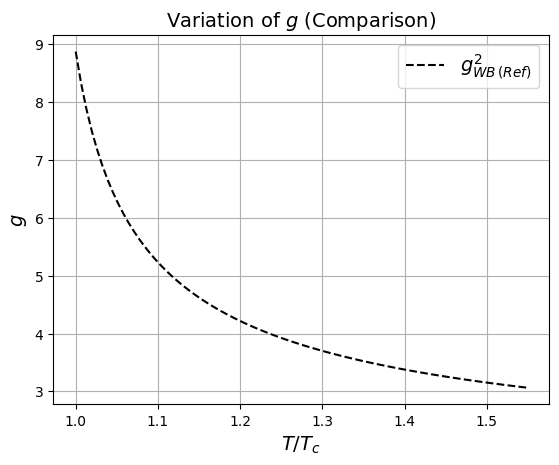

In [8]:
plt.figure()
lambda_WB, Ts_Tc_WB = 2.6, 0.57
g2_ref = 48 * np.pi**2 / (((11 * 3 )- (2 * 3)) * np.log((lambda_WB * (Temp/Tc - Ts_Tc_WB))**2))

plt.plot(Temp[30:116]/Tc,  np.sqrt(g2_ref[30:116]), label='$g^2_{WB\,(Ref)}$', color='black', linestyle='--')

plt.ylabel('$g$', fontsize=14)
plt.xlabel('$T/T_c$', fontsize=14)
plt.legend(fontsize=14)
plt.title('Variation of $g$ (Comparison)', fontsize=14)
plt.grid(True)
plt.savefig("./plots/g2.jpg")
plt.show()


C:\Users\vijay\AppData\Local\Temp\ipykernel_126628\3123014074.py:10: RuntimeWarning: invalid value encountered in log
  tauqinv_wb = (nc**2 - 1)/nc * (g2_ref * Temp) / (8 * np.pi) * np.log(2 * kwb / g2_ref) * 5.07
C:\Users\vijay\AppData\Local\Temp\ipykernel_126628\3123014074.py:11: RuntimeWarning: invalid value encountered in log
  tauginv_wb = 2 * nc * g2_ref * Temp / (8 * np.pi) * np.log(2 * kwb / g2_ref) * 5.07


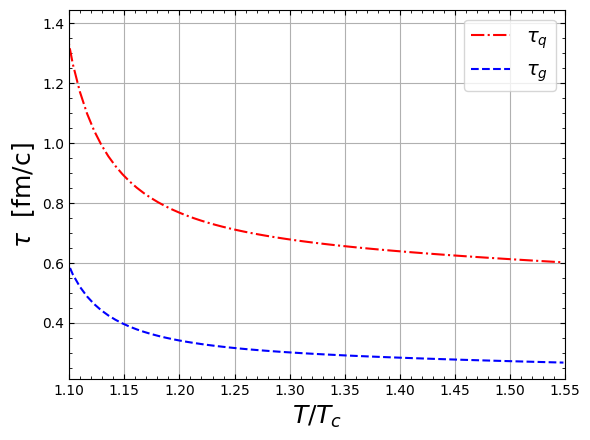

In [9]:
plt.figure()
nc = 3
nf = 3

kwb = 18.5
tauqinv_wb = (nc**2 - 1)/nc * (g2_ref * Temp) / (8 * np.pi) * np.log(2 * kwb / g2_ref) * 5.07
tauginv_wb = 2 * nc * g2_ref * Temp / (8 * np.pi) * np.log(2 * kwb / g2_ref) * 5.07
tauq_wb = tauqinv_wb**(-1)
taug_wb = tauginv_wb**(-1)

plt.plot(Temp[45:116]/Tc, tauq_wb[45:116], label = r'$\tau_{q}$', linestyle='-.', color='red')
plt.plot(Temp[45:116]/Tc, taug_wb[45:116], label = r'$\tau_{g}$', linestyle='--', color='blue')
plt.ylabel(r"$\tau$  [fm/c]", fontsize=18)
plt.xlabel(r"$T/T_c$", fontsize=18)
plt.legend(loc='best', fontsize=14)
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.minorticks_on()
plt.grid(True)
plt.xlim(1.1,1.55)
plt.savefig("./plots/Tau.jpg", dpi=600, bbox_inches='tight')
plt.show()
pd.DataFrame({
    "T": Temp,
    "tauq_wb": tauq_wb,
    "taug_wb" : taug_wb
}).to_csv("tau.csv", index=False)


In [10]:
coeff = (4*np.pi) / (3 * (2*np.pi)**3)
MUB = Mub / 3
e = np.sqrt(4*np.pi/137)

def integrand_u_wb_quark(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1/(np.exp((En-Mu)/Tmp)+1)
    return (p**4/En**2)*(4/9)*(tq/Tmp)*fq*(1-fq)*6*5.07* e**2

def integrand_u_wb_anti(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1/(np.exp((En+Mu)/Tmp)+1)
    return (p**4/En**2)*(4/9)*(tq/Tmp)*fq*(1-fq)*6*5.07* e**2

eta_ui_wb = []
for mass_ud, Tmp, tq, Mu in zip(mud, Temp, tauq_wb, MUB):
    i1,_ = quad(integrand_u_wb_quark,0,10,args=(mass_ud,Tmp,tq,Mu))
    i2,_ = quad(integrand_u_wb_anti,0,10,args=(mass_ud,Tmp,tq,Mu))
    eta_ui_wb.append(i1+i2)

eta_u_wb = np.array(eta_ui_wb)

def integrand_d_wb_quark(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1/(np.exp((En-Mu)/Tmp)+1)
    return (p**4/En**2)*(1/9)*(tq/Tmp)*fq*(1-fq)*6*5.07* e**2

def integrand_d_wb_anti(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1/(np.exp((En+Mu)/Tmp)+1)
    return (p**4/En**2)*(1/9)*(tq/Tmp)*fq*(1-fq)*6*5.07* e**2

eta_di_wb = []
for mass_ud, Tmp, tq, Mu in zip(mud, Temp, tauq_wb, MUB):
    i1,_ = quad(integrand_d_wb_quark,0,10,args=(mass_ud,Tmp,tq,Mu))
    i2,_ = quad(integrand_d_wb_anti,0,10,args=(mass_ud,Tmp,tq,Mu))
    eta_di_wb.append(i1+i2)

eta_d_wb = np.array(eta_di_wb)

def integrand_s_wb_quark(p, mass_s, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1/(np.exp((En-Mu)/Tmp)+1)
    return (p**4/En**2)*(1/9)*(tq/Tmp)*fq*(1-fq)*6*5.07* e**2

def integrand_s_wb_anti(p, mass_s, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1/(np.exp((En+Mu)/Tmp)+1)
    return (p**4/En**2)*(1/9)*(tq/Tmp)*fq*(1-fq)*6*5.07* e**2

eta_si_wb = []
for mass_s, Tmp, tq, Mu in zip(ms, Temp, tauq_wb, MUB):
    i1,_ = quad(integrand_s_wb_quark,0,10,args=(mass_s,Tmp,tq,Mu))
    i2,_ = quad(integrand_s_wb_anti,0,10,args=(mass_s,Tmp,tq,Mu))
    eta_si_wb.append(i1+i2) 

eta_s_wb = np.array(eta_si_wb)

sigma = (eta_u_wb + eta_d_wb + eta_s_wb) * coeff 
sigT = sigma/Temp


C:\Users\vijay\AppData\Local\Temp\ipykernel_126628\2390016315.py:20: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  i1,_ = quad(integrand_u_wb_quark,0,10,args=(mass_ud,Tmp,tq,Mu))
C:\Users\vijay\AppData\Local\Temp\ipykernel_126628\2390016315.py:21: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  i2,_ = quad(integrand_u_wb_anti,0,10,args=(mass_ud,Tmp,tq,Mu))
C:\Users\vijay\AppData\Local\Temp\ipykernel_126628\2390016315.py:40: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  i1,_ = quad(integrand_d_wb_quark,0,10,args=(mass_ud,Tmp,tq,Mu))
C:\Users\vijay\AppData\Local\Temp\ipykernel_126628\2390016315.py:41: IntegrationWarning: The occur

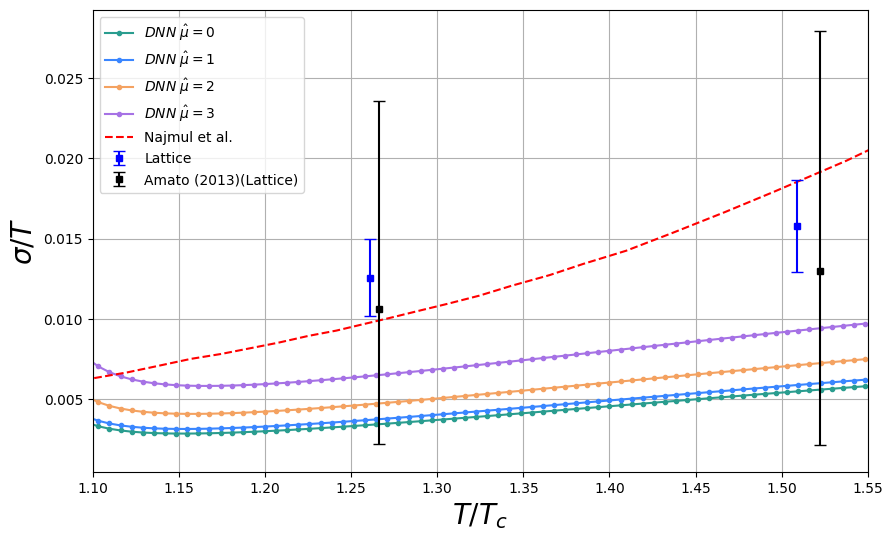

In [11]:
plt.figure(figsize=(10,6))

plt.plot(Temp[45:116]/Tc, sigT[45:116], label=r'$DNN$ $\hat{\mu} = 0$', marker='.', color='#2A9D8F')
plt.plot(Temp[277:348]/Tc, sigT[277:348], label=r'$DNN$ $\hat{\mu} = 1$', marker='.',color='#3A86FF')
plt.plot(Temp[509:580]/Tc, sigT[509:580], label=r'$DNN$ $\hat{\mu} = 2$', marker='.', color='#F4A261')
plt.plot(Temp[741:812]/Tc, sigT[741:812], label=r'$DNN$ $\hat{\mu} = 3$', marker='.',color='#A672E5')
plt.plot(T_nj,sigt_nj, 'r--', label = r'Najmul et al.')
plt.errorbar(Tp1, el_mid , yerr=el_err,
             fmt='s', color='blue', markersize=4, capsize=4, elinewidth=1.5, label = "Lattice")
plt.errorbar(
    Tp2, sig_mid,
    yerr=[err_low, err_high],   # asymmetric errors
    fmt='s', color='k',
    markersize=4, capsize=4,
    elinewidth=1.5,
    label="Amato (2013)(Lattice)"
)
plt.ylabel(r"$\sigma/T$", fontsize=20)
plt.xlabel("$T/T_c$", fontsize=20)
plt.legend(loc='best')
plt.grid(True)
plt.xlim(1.1, 1.55)
plt.savefig("./plots/sigmabyT.jpg")
plt.show()


In [12]:
pd.DataFrame({
    "T": Temp,
    "MuB": Mub,
    "sigma/T": sigT
}).to_csv("SigmaBTemp_center.csv", index=False)


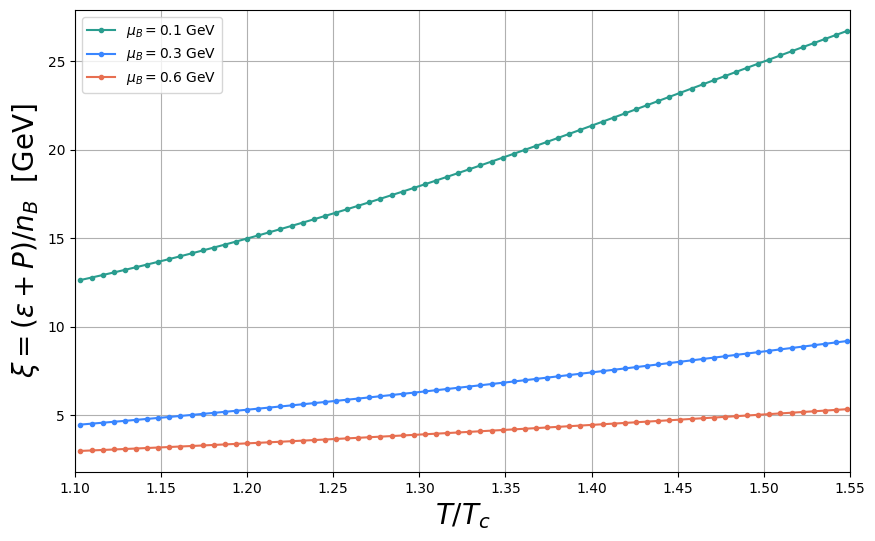

In [16]:
Tc = 0.155
muB_list = [0.1, 0.3, 0.6]
colors   = {0.1: "#2A9D8F", 0.3: "#3A86FF", 0.6: "#E76F51"}

T_all = np.sort(np.unique(pd.read_csv(os.path.join(ROOT, "Thermo_data_central.csv"))["T"].to_numpy()))
T_fix = T_all[(T_all/Tc >= 1.10) & (T_all/Tc <= 1.55)]
plt.figure(figsize=(10, 6))
rows = []

for muB in muB_list:
    muB_arr = np.full(T_fix.shape, muB)
    mud_f, ms_f, mg_f, P_f, s_f, eps_f, tr_f, nB_f, T_f, Mu_f = emulator(T_fix, muB_arr)

    xi_f =(eps_f + P_f) / nB_f          # enthalpy per baryon [GeV]

    plt.plot(T_f/Tc, xi_f, marker=".", color=colors[muB], label=rf"$\mu_B={muB}$ GeV")
    for k in range(len(T_f)):
        rows.append({"T": T_f[k], "MuB": muB, "xi": xi_f[k]})

plt.xlabel(r"$T/T_c$", fontsize=20)
plt.ylabel(r"$\xi=(\varepsilon+P)/n_B$  [GeV]", fontsize=20)
plt.legend()
plt.grid(True)
plt.xlim(1.1, 1.55)
plt.savefig("./plots/enthalpy_MuB_fixed.jpg", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame(rows).to_csv("enthalpy_fixed_MuB.csv", index=False)


In [18]:
from scipy.integrate import quad
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

Tc = 0.155
nc = 3
lambda_WB, Ts_Tc_WB, kwb = 2.6, 0.57, 18.5
coeff = (4*np.pi) / (3*(2*np.pi)**3)
e = np.sqrt(4*np.pi/137)

muB_list = [0.1, 0.3, 0.6]
colors   = {0.1: "#2A9D8F", 0.3: "#3A86FF", 0.6: "#E76F51"}

_thermo = pd.read_csv(os.path.join(ROOT, "Thermo_data_central.csv"))
T_data  = np.sort(np.unique(_thermo["T"].to_numpy(dtype=float)))
T_fix   = T_data[(T_data/Tc >= 1.10) & (T_data/Tc <= 1.55)]

def sig_u_q(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    return (p**4 / En**2) * (2/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_u_a(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    return (p**4 / En**2) * (2/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_d_q(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    return (p**4 / En**2) * (1/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_d_a(p, mass_ud, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    return (p**4 / En**2) * (1/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_s_q(p, mass_s, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    return (p**4 / En**2) * (1/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def sig_s_a(p, mass_s, Tmp, tq, Mu):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    return (p**4 / En**2) * (1/3)**2 * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e**2

def I_u_q(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (+2/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En - (1/3) * xi)

def I_u_a(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (-2/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En + (1/3) * xi)

def I_d_q(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (-1/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En - (1/3) * xi)

def I_d_a(p, mass_ud, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_ud**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (+1/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En + (1/3) * xi)

def I_s_q(p, mass_s, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En - Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (-1/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En - (1/3) * xi)

def I_s_a(p, mass_s, Tmp, tq, Mu, energy, pressure, baryon):
    En = np.sqrt(p**2 + mass_s**2)
    fq = 1 / (np.exp((En + Mu) / Tmp) + 1)
    xi = (energy + pressure) / baryon
    return (p**4 / En**2) * (+1/3) * (tq / Tmp) * fq * (1 - fq) * 6 * 5.07 * e * (En + (1/3) * xi)

fixed, rows = {}, []

for muB_val in muB_list:
    print("fixed MuB =", muB_val, flush=True)
    muB_arr = np.full(T_fix.shape, muB_val, dtype=np.float64)
    mud_f, ms_f, mg_f, pr_f, s_f, en_f, tr_f, nB_f, T_f, Mu_f = emulator(T_fix, muB_arr)

    g2_f   = 48*np.pi**2 / (((11*nc) - (2*nc)) * np.log((lambda_WB*(T_f/Tc - Ts_Tc_WB))**2))
    tauq_f = ((nc**2 - 1)/nc * (g2_f*T_f)/(8*np.pi) * np.log(2*kwb/g2_f) * 5.07) ** (-1)   # fm
    Mu_q   = Mu_f / 3.0

    sig_list, I_list = [], []
    for mass_ud, mass_s, Tmp, tq, Mu, En_, Pr_, Ba_ in zip(mud_f, ms_f, T_f, tauq_f, Mu_q, en_f, pr_f, nB_f):
        mass_ud, mass_s, Tmp, tq, Mu, En_, Pr_, Ba_ = map(float, (mass_ud, mass_s, Tmp, tq, Mu, En_, Pr_, Ba_))

        a = (mass_ud, Tmp, tq, Mu)
        b = (mass_s,  Tmp, tq, Mu)
        sig_tot = (quad(sig_u_q, 0, 10, args=a)[0] + quad(sig_u_a, 0, 10, args=a)[0]
                 + quad(sig_d_q, 0, 10, args=a)[0] + quad(sig_d_a, 0, 10, args=a)[0]
                 + quad(sig_s_q, 0, 10, args=b)[0] + quad(sig_s_a, 0, 10, args=b)[0])

        a = (mass_ud, Tmp, tq, Mu, En_, Pr_, Ba_)
        b = (mass_s,  Tmp, tq, Mu, En_, Pr_, Ba_)
        I_tot = (quad(I_u_q, 0, 10, args=a)[0] + quad(I_u_a, 0, 10, args=a)[0]
               + quad(I_d_q, 0, 10, args=a)[0] + quad(I_d_a, 0, 10, args=a)[0]
               + quad(I_s_q, 0, 10, args=b)[0] + quad(I_s_a, 0, 10, args=b)[0])

        sig_list.append(sig_tot)
        I_list.append(I_tot)

    sigma_f = np.array(sig_list) * coeff
    I1_f    = np.array(I_list)   * coeff
    sigT_f  = sigma_f / T_f
    IT_f    = I1_f / T_f**2
    S_f     = IT_f / sigT_f

    fixed[muB_val] = {"T": T_f, "sigma": sigma_f, "I1": I1_f, "sigT": sigT_f, "IT": IT_f, "S": S_f}
    for k in range(len(T_f)):
        rows.append({"T": T_f[k], "MuB": muB_val, "sigma": sigma_f[k], "sigma/T": sigT_f[k],
                     "I1": I1_f[k], "I1/T2": IT_f[k], "S": S_f[k]})

pd.DataFrame(rows).to_csv("Seebeck_B0_fixed_MuB.csv", index=False)


fixed MuB = 0.1
fixed MuB = 0.3
fixed MuB = 0.6


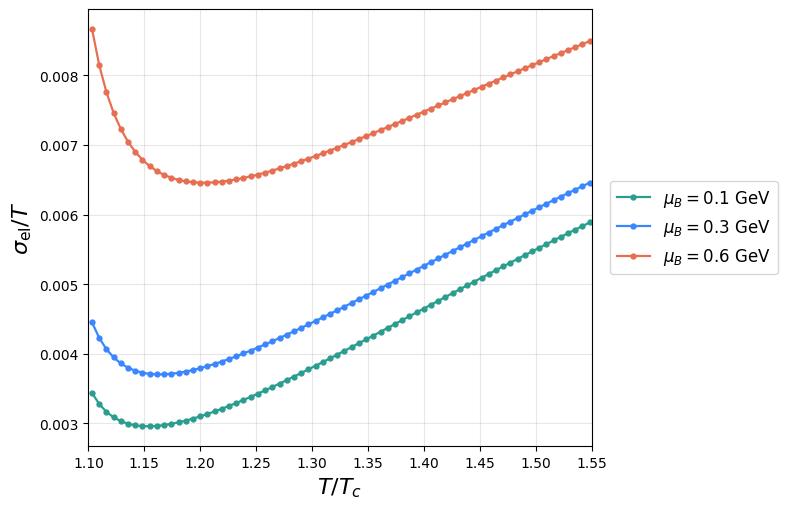

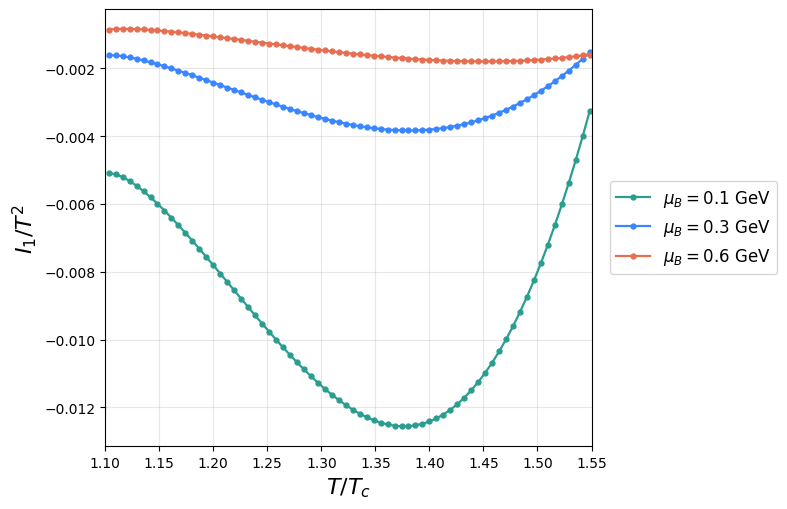

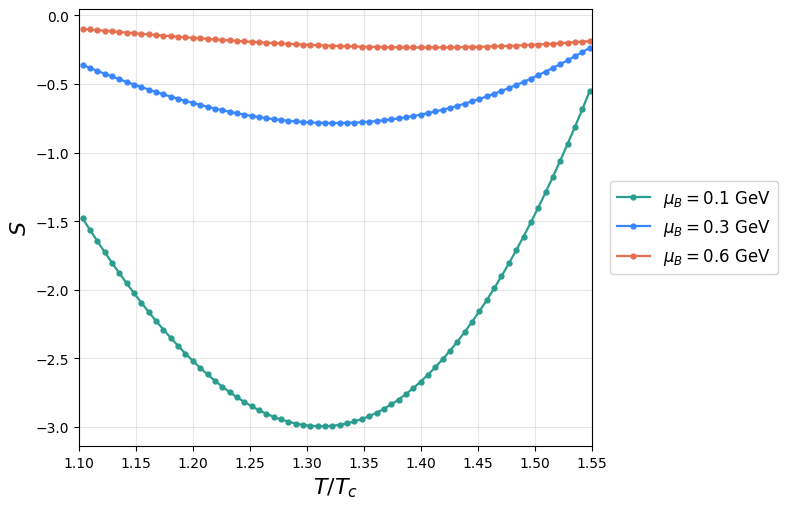

In [24]:
panels = [
    ("sigT", r"$\sigma_{\mathrm{el}}/T$"),
    ("IT",   r"$I_1/T^2$"),
    ("S",    r"$S$"),
]

for key, ylab in panels:
    fig, ax = plt.subplots(figsize=(8, 5.2))
    for muB_val in muB_list:
        r = fixed[muB_val]
        ax.plot(
            r["T"] / Tc, r[key],
            color=colors[muB_val],
            marker="o", markersize=3.5, linewidth=1.6,
            label=rf"$\mu_B = {muB_val}$ GeV",
        )
    ax.set_xlabel(r"$T/T_c$", fontsize=16)
    ax.set_ylabel(ylab, fontsize=16)
    ax.set_xlim(1.10, 1.55)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=12)
    fig.tight_layout()
    plt.show()


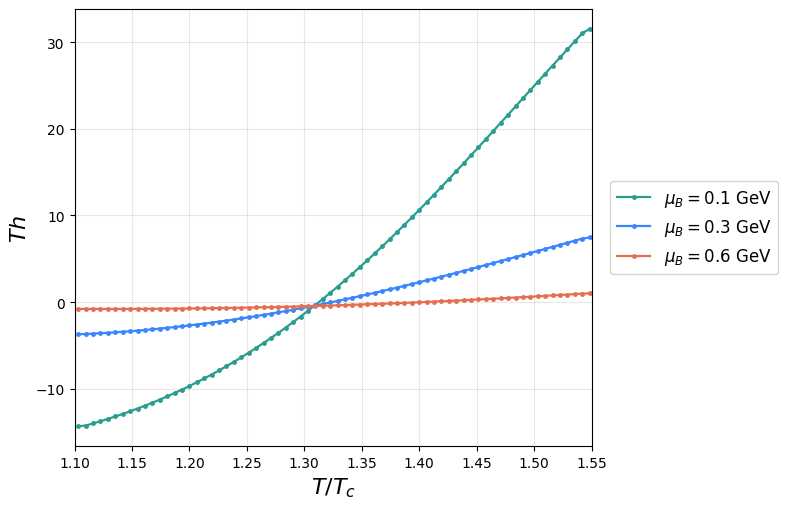

In [31]:
# Thomson coefficient at fixed MuB = 0.1, 0.3, 0.6 GeV
# Th = T * dS/dT

fig, ax = plt.subplots(figsize=(8, 5.2))
rows = []

for muB_val in muB_list:
    r = fixed[muB_val]
    T = np.asarray(r["T"], dtype=float)
    S = np.asarray(r["S"], dtype=float)
    Th = T * np.gradient(S, T)
    r["Th"] = Th
    ax.plot(
        T / Tc, Th,
        color=colors[muB_val],
        marker="o", markersize=2.5, linewidth=1.6,
        label=rf"$\mu_B = {muB_val}$ GeV",
    )
    for k in range(len(T)):
        rows.append({"T": float(T[k]), "MuB": muB_val, "S": float(S[k]), "Th": float(Th[k])})

ax.set_xlabel(r"$T/T_c$", fontsize=16)
ax.set_ylabel(r"$Th$", fontsize=16)
ax.set_xlim(1.10, 1.55)
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=12)
fig.tight_layout()
plt.savefig("./plots/Thomson_MuB_fixed.jpg", dpi=200, bbox_inches="tight")
plt.show()

pd.DataFrame(rows).to_csv("thomson_fixed_MuB.csv", index=False)


MuB = 0.1
MuB = 0.3
MuB = 0.6


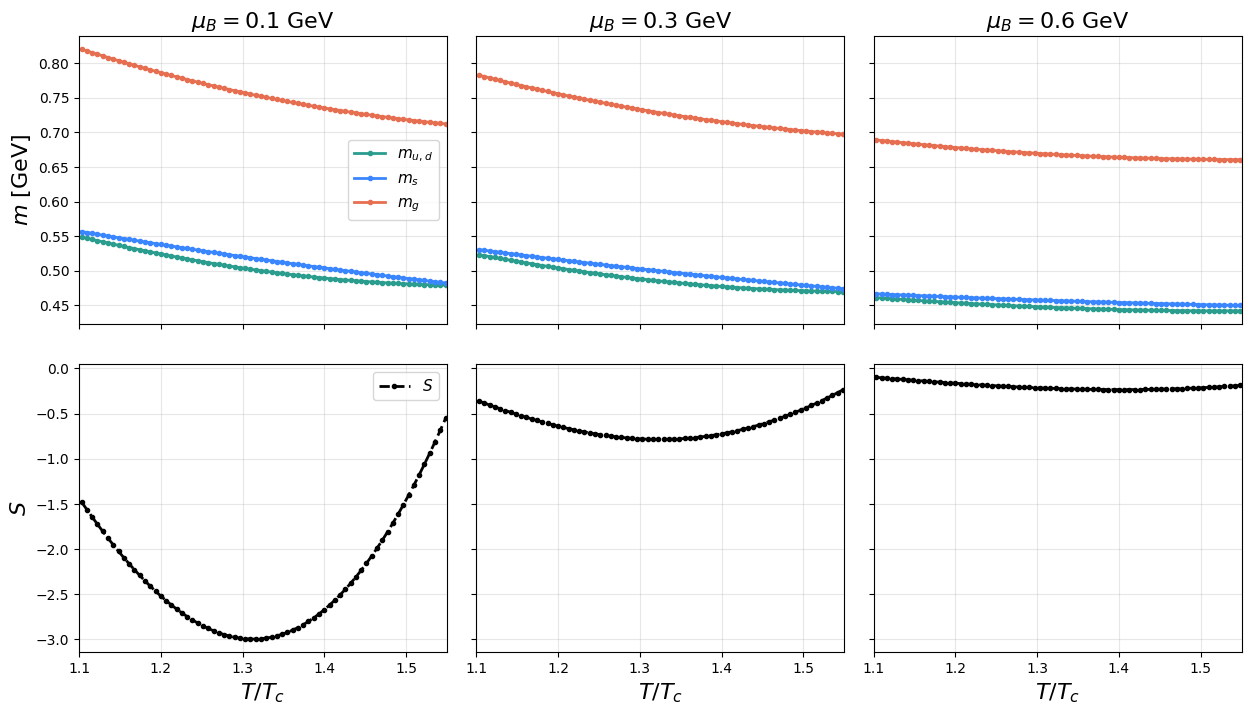

In [32]:
# Masses (top row) and Seebeck S (bottom row) for MuB = 0.1, 0.3, 0.6 GeV

fig, axes = plt.subplots(
    2, 3, sharex=True, sharey="row", figsize=(15, 8),
    gridspec_kw={"hspace": 0.14, "wspace": 0.08},
)

for j, muB in enumerate(muB_list):
    print("MuB =", muB, flush=True)
    r = fixed[muB]
    muB_arr = np.full(np.asarray(r["T"]).shape, muB, dtype=np.float64)
    mud_f, ms_f, mg_f, pr_f, s_f, en_f, tr_f, nB_f, T_f, Mu_f = emulator(r["T"], muB_arr)
    x = np.asarray(T_f, dtype=float) / Tc
    ax_m, ax_S = axes[0, j], axes[1, j]

    ax_m.plot(x, np.asarray(mud_f), color="#2A9D8F", lw=2, marker="o", ms=3,
              label=r"$m_{u,d}$")
    ax_m.plot(x, np.asarray(ms_f), color="#3A86FF", lw=2, marker="o", ms=3,
              label=r"$m_s$")
    ax_m.plot(x, np.asarray(mg_f), color="#E76F51", lw=2, marker="o", ms=3,
              label=r"$m_g$")
    ax_m.set_title(rf"$\mu_B = {muB}$ GeV", fontsize=16)
    ax_m.grid(True, alpha=0.3)

    ax_S.plot(x, r["S"], color="black", lw=2, ls="--", marker="o", ms=3,
              label=r"$S$")
    ax_S.set_xlabel(r"$T/T_c$", fontsize=16)
    ax_S.set_xlim(1.10, 1.55)
    ax_S.grid(True, alpha=0.3)

axes[0, 0].set_ylabel(r"$m$ [GeV]", fontsize=16)
axes[1, 0].set_ylabel(r"$S$", fontsize=16)
axes[0, 0].legend(loc="center right", frameon=True, fontsize=11)
axes[1, 0].legend(loc="upper right", frameon=True, fontsize=11)

fig.tight_layout()
plt.savefig("./plots/mass_and_Seebeck_grid.jpg", dpi=200, bbox_inches="tight")
plt.show()
